<a href="https://colab.research.google.com/github/SimplesJohn/IA_Embarquee_Projet_Etudiant/blob/model_training/TP_IA_EMBARQUEE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **PRACTICAL SESSION 1** — Deep Learning for predictive maintenance

The dataset used is the **AI4I 2020** Predictive Maintenance Dataset, which contains 10,000 instances of industrial sensor data. Each instance represents the operating condition of a machine and is associated with a label indicating whether a failure has occurred and, if so, what type of failure it is.

The 5 possible labels are:



*   **TWF**: Tool Wear Failure
*   **HDF**: Heat Dissipation Failure
*   **PWF**: Power Failure
*   **OSF**: Overstrain Failure
*   **RNF**: Random Failure


The data is available on eCAMPUS as CSV file called: "ai4i2020.csv"



## **PRACTICAL SESSION Goal** — Ceate a deep leanring model allowing to realize a predictive maintenance mission

## **1 - Analysis of the dataset**



All libraries used ***SHOULD BE PLACED*** in the code cell below

In [6]:
# --- Data Manipulation & Numerical Operations ---
import pandas as pd  # Used for data manipulation and analysis (handling DataFrames)
import numpy as np   # Used for numerical computing and array operations

# --- Data Visualization ---
import matplotlib.pyplot as plt  # Core library for creating plots, graphs, and charts
import seaborn as sns            # Statistical data visualization (great for correlation matrices)

# --- Machine Learning: Preprocessing & Evaluation (Scikit-Learn) ---
from sklearn.model_selection import train_test_split  # Splits the dataset into training and testing subsets
from sklearn.preprocessing import StandardScaler      # Standardizes features by removing the mean and scaling to unit variance
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, multilabel_confusion_matrix # Evaluation metrics and visualization for multi-label classification

# --- Deep Learning Framework (TensorFlow/Keras) ---
import tensorflow as tf
from tensorflow.keras import layers, models         # Core modules for building neural network architectures
from tensorflow.keras.models import Sequential      # Linear stack of layers for the neural network
from tensorflow.keras.layers import Dense           # Regular densely-connected (fully connected) neural network layers
from tensorflow.keras.metrics import Precision, Recall # Crucial metrics for evaluating model performance on imbalanced data

# --- Handling Imbalanced Datasets ---
from imblearn.over_sampling import RandomOverSampler # Balances the training data by duplicating minority class examples


**QUESTION:** Load dataset and display some lines of the csv file.

In [7]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [8]:
file_path = '/content/drive/MyDrive/Colab Notebooks/ai4i2020.csv'
df = pd.read_csv(file_path)
display(df.head())

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


**QUESTION:** Display the distribution of machine failures and non-failures with a bar graph.

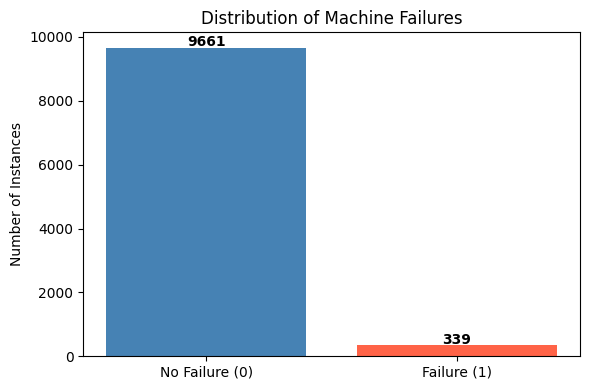

In [9]:
counts = df['Machine failure'].value_counts()
plt.figure(figsize=(6,4))
plt.bar(['No Failure (0)', 'Failure (1)'], counts.values, color=['steelblue', 'tomato'])
plt.title('Distribution of Machine Failures')
plt.ylabel('Number of Instances')

for i, v in enumerate(counts.values):
    plt.text(i, v + 50, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

**ANALYSIS QUESTION:** What do you observe?

*"We observe a massive class imbalance in the dataset. Out of 10000 instances, the vast majority (9961) represent machines operating normally (class 0), while only a very small fraction (339) represent machines that have experienced a failure (class 1)"*

**ANALYSIS QUESTION:** What will be the consequence of this phenomenon on the model's learning?

*Because of this extreme imbalance, the model risks becoming "lazy" and systematically predicting "0" (no failure). It will achieve an artificially high global accuracy (over 96%) but will be incapable of detecting real failures, resulting in a Recall close to zero for the minority class.*

**QUESTION:** Create a bar chart showing the distribution of different failure types (TWF, HDF, PWF, OSF, RNF). Display the exact values above each bar in the chart."

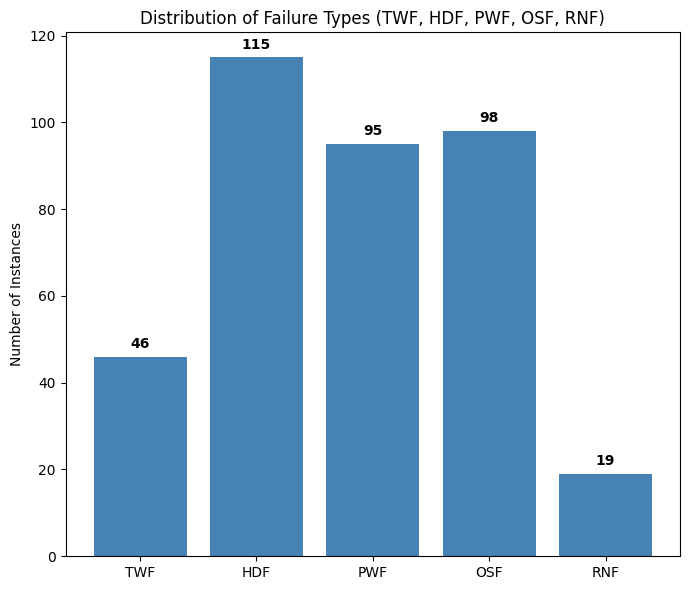

In [10]:
failure_cols = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']
failure_counts = df[failure_cols].sum()

plt.figure(figsize=(7,6))
bars = plt.bar(failure_cols, failure_counts.values, color='steelblue')
plt.title('Distribution of Failure Types (TWF, HDF, PWF, OSF, RNF)')
plt.ylabel('Number of Instances')

for bar, val in zip(bars, failure_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, str(val), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

**ANALYSIS QUESTION:** What do you observe?

*It is observed that HDF (Heat Dissipation Failure) and OSF (Overstrain Failure) are the most frequent causes of breakdown, while RNF (Random Failure) is the least frequent. The failure types are also imbalanced among themselves.*


**QUESTION:** Create a bar chart showing the distribution of failure types (TWF, HDF, PWF, OSF, RNF) among machines that experienced a failure (Machine failure == 1). Additionally, add a "No Specific Failure" category to count cases where a machine failed but no specific failure type was recorded. Display the exact values above each bar in the chart."

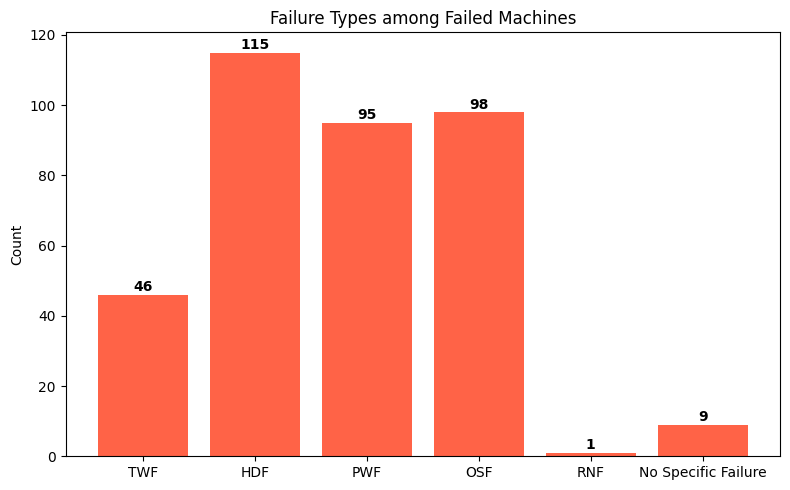

In [11]:
df_failed = df[df['Machine failure'] == 1].copy()
failure_counts_f = df_failed[failure_cols].sum()
no_specific = (df_failed[failure_cols].sum(axis=1) == 0).sum()
failure_counts_f['No Specific Failure'] = no_specific

plt.figure(figsize=(8,5))
bars = plt.bar(failure_counts_f.index, failure_counts_f.values, color='tomato')
plt.title('Failure Types among Failed Machines')
plt.ylabel('Count')

for bar, val in zip(bars, failure_counts_f.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, str(val), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

**ANALYSIS QUESTION:** What do you obsrve comapred to the previous question ? What can you conclude?

*Comparing this chart to the previous one, there is a major discrepancy in the RNF (Random Failure) category. In the full dataset, RNF occurs 19 times, but among the failed machines (Machine failure == 1), it only appears 1 time. This means there are 18 contradictory instances where a Random Failure was recorded (RNF == 1), but the general machine failure flag was not triggered (Machine failure == 0). Additionally, there are 9 instances of "No Specific Failure", where the machine is labeled as broken (Machine failure == 1) but all five specific error flags are 0.*

*In conclusion, the dataset is highly noisy and contains severe label inconsistencies. We have 18 false-negative contradictions (RNF) and 9 false-positive contradictions ("ghost failures"). For a robust Machine Learning pipeline, all these corrupted instances must be removed during preprocessing; otherwise, the loss function will be heavily penalized by contradictory labels. Because the sum of specific failures exceeds the total number of broken machines, it is mathematically proven that a single machine can suffer from multiple failure modes simultaneously.*

**QUESTION:** Display the names of the different columns in the dataset with their respective data types.

In [12]:
print(df.dtypes)
print(f"\nShape: {df.shape}")

UDI                          int64
Product ID                  object
Type                        object
Air temperature [K]        float64
Process temperature [K]    float64
Rotational speed [rpm]       int64
Torque [Nm]                float64
Tool wear [min]              int64
Machine failure              int64
TWF                          int64
HDF                          int64
PWF                          int64
OSF                          int64
RNF                          int64
dtype: object

Shape: (10000, 14)


**ANALYSIS QUESTION:** To train the model, what will be the inputs and outputs (What are the names of the columns that you will use?)? Justify your response.
Remember, you want to predict if the machine will fail, and if so, what kind of failure. You need to yse previous results to jsurtify your response.

#Inputs (Features / X):

*We will use Type, Air temperature [K], Process temperature [K], Rotational speed [rpm], Torque [Nm], and Tool wear [min]. Because these variables represent the physical parameters and sensor readings that directly dictate the mechanical health of the machine. we will explicitly EXCLUDE UDI and Product ID because they are arbitrary strings/integers that carry no predictive physical meaning and would only introduce noise. we must also exclude the general Machine failure column from the inputs to prevent critical data leakage (if the network sees this column, it already knows the answer without analyzing the sensors). The Type column (L, M, H) is highly relevant to machine quality but must be numerically encoded before training.*

#Outputs (Labels / Y):

*We will use the 5 specific failure columns: TWF, HDF, PWF, OSF, and RNF. Because the goal is to predict if a failure occurs and what kind. As proven in the previous analysis, a single machine can experience multiple failure types simultaneously, making this a Multi-label classification problem. By predicting these 5 columns concurrently, we cover both "if" it fails (if any output is 1) and "what kind" it is. Furthermore, based on our previous discovery of the 18 contradictory RNF records and the 9 "No Specific Failure" records, we must clean these anomalies from our Inputs and Outputs during preprocessing to ensure the STM32 model trains on mathematically consistent ground truth data.*

## **2- Train model Without balancing the dataset**

---



In this section, you must build and train a model without rebalancing the dataset.

**QUESTION:** Create X_train, Y_train, X_test, and Y_test. How many elements are present in X_train, Y_train, X_test, and Y_test? (Print the values)

In [13]:

df_prep = df.copy()

# We convert to string, remove spaces and capitalize
df_prep['Type'] = df_prep['Type'].astype(str).str.strip().str.upper()
df_prep['Type'] = df_prep['Type'].map({'L': 0, 'M': 1, 'H': 2})

failure_cols = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']
# We remove inconsistencies
df_prep = df_prep.drop(df_prep[(df_prep['RNF'] == 1) & (df_prep['Machine failure'] == 0)].index, errors='ignore')
df_prep = df_prep.drop(df_prep[(df_prep['Machine failure'] == 1) & (df_prep[failure_cols].sum(axis=1) == 0)].index, errors='ignore')

# 4. DEFINE X and Y
input_features = ['Type', 'Air temperature [K]', 'Process temperature [K]',
                  'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']

# We remove any row that has been empty before creating X and Y
df_prep = df_prep.dropna(subset=input_features + failure_cols)

X = df_prep[input_features].values
Y = df_prep[failure_cols].values

# VERIFICATION: If this prints > 0, the error will disappear
print(f"Filas listas para procesar: {len(X)}")

# 5. SPLIT
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# 6. NORMALIZATION
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f"X_train shape: {X_train.shape}")
print(f"Y_train shape: {Y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"Y_test shape: {Y_test.shape}")

Filas listas para procesar: 9973
X_train shape: (7978, 6)
Y_train shape: (7978, 5)
X_test shape: (1995, 6)
Y_test shape: (1995, 5)


**QUESTION** Code below the model architecture

In [14]:
# Model architecture: Dynamic and optimized for STM32 deployment
model = Sequential([
    # Input layer: Automatically adapts to the 6 features
    # We use 32 neurons as a balance between performance and memory usage
    Dense(32, activation='relu', input_shape=(X_train.shape[1],)),

    # Hidden layer: Small footprint to save RAM and Flash on the microcontroller
    Dense(16, activation='relu'),

    # Output layer: Dynamic size for the 5 failure types (TWF, HDF, PWF, OSF, RNF)
    # Sigmoid is mandatory here for independent Multi-label classification
    Dense(Y_train.shape[1], activation='sigmoid')
])

# Compile the model
# Binary crossentropy is used to evaluate each failure independently
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['binary_accuracy'])

# Display the model summary to check the parameter count
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │            85 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 837 (3.27 KB)

 Trainable params: 837 (3.27 KB)

 Non-trainable params: 0 (0.00 B)

**QUESTION** Code below the algorithms allowing to train model

**WARNING!** You need to plot the training and test accuracy and loss to check if our model is overfitting

Epoch 1/40
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - binary_accuracy: 0.9242 - loss: 0.2408 - val_binary_accuracy: 0.9937 - val_loss: 0.0508
Epoch 2/40
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - binary_accuracy: 0.9927 - loss: 0.0478 - val_binary_accuracy: 0.9937 - val_loss: 0.0416
Epoch 3/40
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - binary_accuracy: 0.9927 - loss: 0.0412 - val_binary_accuracy: 0.9937 - val_loss: 0.0363
Epoch 4/40
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - binary_accuracy: 0.9927 - loss: 0.0366 - val_binary_accuracy: 0.9937 - val_loss: 0.0318
Epoch 5/40
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - binary_accuracy: 0.9927 - loss: 0.0326 - val_binary_accuracy: 0.9937 - val_loss: 0.0277
Epoch 6/40
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - binary_accuracy: 0.9927 - loss: 0.0291 - val_binary_accuracy: 0.9937 - val_loss: 0.0246
Epoch 7/40
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - binary_accuracy: 0.9928 - loss: 0.0262 - val_binary_accuracy: 0.9945 - val_loss: 0.0229
Epoch 

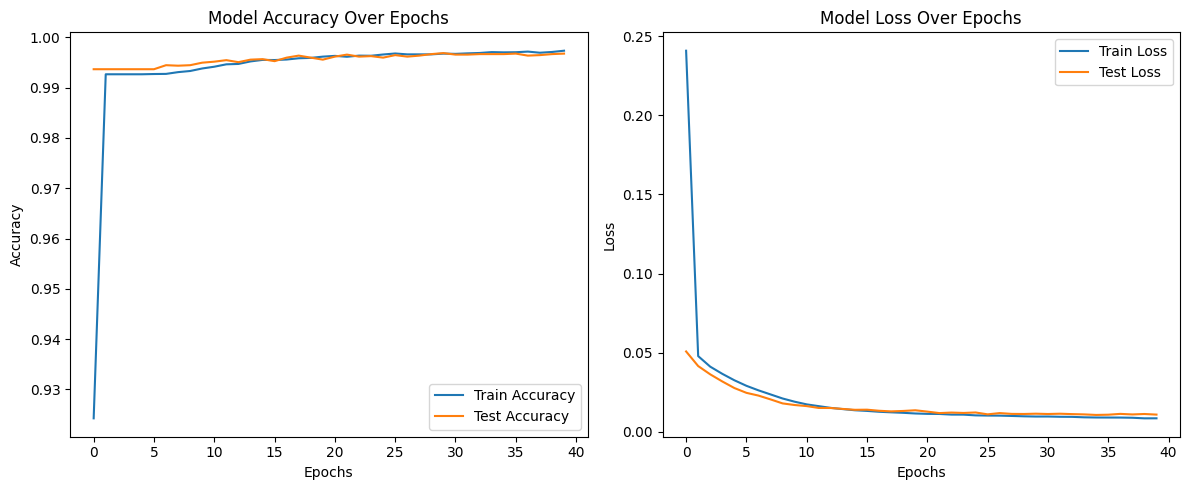


Performance on the TRAIN set, ACCURACY = 0.9972670078277588
Performance on the TEST set, ACCURACY = 0.9967920780181885


In [15]:
# --- Training the model ---
history = model.fit(
    X_train,
    Y_train,
    epochs=40,
    batch_size=32,
    validation_data=(X_test, Y_test),
    verbose=1
)

# --- Plot training & validation accuracy and loss ---
plt.figure(figsize=(12, 5))

# Plot 1: Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['binary_accuracy'], label='Train Accuracy')
plt.plot(history.history['val_binary_accuracy'], label='Test Accuracy')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Model Accuracy Over Epochs")
plt.legend()

# Plot 2: Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Test Loss')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Model Loss Over Epochs")
plt.legend()

plt.tight_layout()
plt.show()

# --- ACCURACY ON THE TRAINING AND TEST SETS ---
loss_train, acc_train = model.evaluate(X_train, Y_train, batch_size=32, verbose=0)
loss_test, acc_test = model.evaluate(X_test, Y_test, batch_size=32, verbose=0)

print(f"\nPerformance on the TRAIN set, ACCURACY = {acc_train}")
print(f"Performance on the TEST set, ACCURACY = {acc_test}")

**QUESTION** Plot the confusion matrix and the classification report

**Tips:**

*   classification report link

> https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html

*   Matrix confusion

> https://scikit-learn.org/stable/modules/generated/sklearn.metrics.ConfusionMatrixDisplay.html





63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Classification Report:
              precision    recall  f1-score   support

         TWF       0.00      0.00      0.00         5
         HDF       0.71      0.43      0.54        23
         PWF       1.00      0.78      0.88        23
         OSF       0.82      0.82      0.82        11
         RNF       0.00      0.00      0.00         1

   micro avg       0.86      0.59      0.70        63
   macro avg       0.51      0.41      0.45        63
weighted avg       0.77      0.59      0.66        63
 samples avg       0.02      0.02      0.02        63



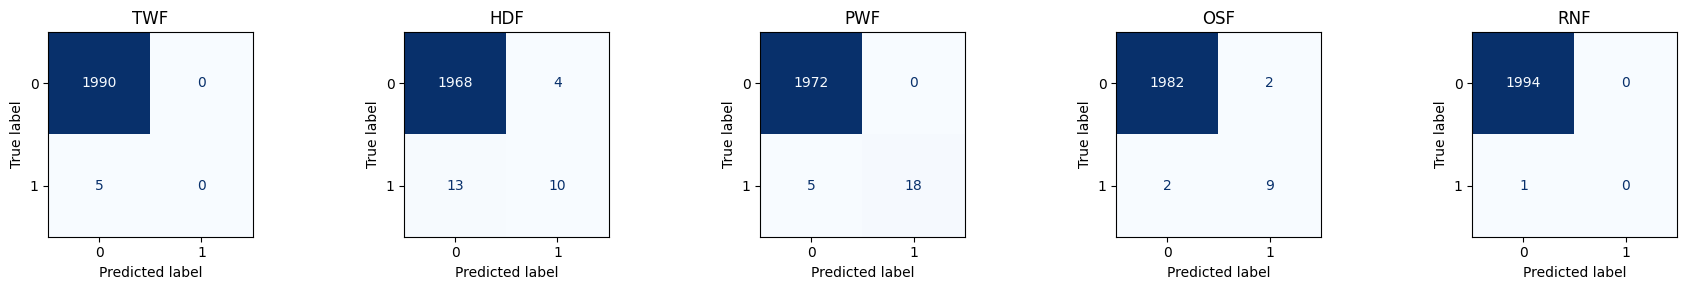

In [16]:
# Predictions (Threshold at 0.5 for sigmoid outputs)
Y_pred = (model.predict(X_test) > 0.5).astype(int)

# Classification Report
print("Classification Report:")
print(classification_report(Y_test, Y_pred, target_names=failure_cols, zero_division=0))

# Confusion Matrices for each specific label
fig, axes = plt.subplots(1, 5, figsize=(18, 3))
mcm = multilabel_confusion_matrix(Y_test, Y_pred)

for i, (ax, label) in enumerate(zip(axes, failure_cols)):
    ConfusionMatrixDisplay(mcm[i]).plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(label)

plt.tight_layout()
plt.show()

**ANALYSIS QUESTION** What do you observe? What can you conclude?

  *The classification report reveals a highly inconsistent performance. While some classes like OSF and PWF show surprisingly good results, the model completely fails to detect TWF and RNF, yielding a 0.00 Recall.*

  *We must note that the support (the number of actual failure instances in the test set) is extremely low (only 5 instances for TWF and 1 for RNF). This small sample size means the high metrics in other classes are not statistically robust and cannot be trusted for a real-world deployment.*

  *The model is biased toward the classes with slightly more representation and completely ignores the rarest ones. In a predictive maintenance context, missing even one type of failure (like Tool Wear) could lead to catastrophic machine damage. This confirms that Accuracy is a deceptive metric here (since it remains high) and underscores the absolute necessity of the next step: Dataset Balancing to improve the Recall across all failure modes.*

## **3- Train model With balancing the dataset**

---

 Methods for rebalancing a dataset:


*   Use oversampling techniques (e.g., SMOTE) to generate synthetic data for minority classes


> https://imbalanced-learn.org/stable/references/generated/imblearn.over_sampling.SMOTE.html



*   Apply undersampling techniques (e.g., random undersampling, Tomek Links, Edited Nearest Neighbors) to reduce the majority class size



> https://imbalanced-learn.org/stable/references/generated/imblearn.under_sampling.RandomUnderSampler.html



*   Use class weighting during model training to penalize errors on minority classes



> https://www.tensorflow.org/tutorials/structured_data/imbalanced_data?hl=fr


**QUESTION:** Create X_train, Y_train, X_test, and Y_test. How many elements are present in X_train, Y_train, X_test, and Y_test? (Print the values)

In [17]:

df_clean = df.copy()

df_clean['Type'] = df_clean['Type'].astype(str).str.strip().str.upper()
mapping = {'L': 0, 'M': 1, 'H': 2}
df_clean['Type'] = df_clean['Type'].map(mapping)

# We define the columns
feature_cols = ['Type', 'Air temperature [K]', 'Process temperature [K]',
                'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']
label_cols = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']

df_clean = df_clean.dropna(subset=feature_cols + label_cols)

X = df_clean[feature_cols].values
Y = df_clean[label_cols].values

# 3. Split the data (80% train, 20% test)
X_train_raw, X_test_raw, Y_train_raw, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# 4. Apply RandomOverSampler to the training set only
ros = RandomOverSampler(random_state=42)
y_train_any = (Y_train_raw.sum(axis=1) > 0).astype(int)
X_train_res, _ = ros.fit_resample(X_train_raw, y_train_any)

# Restore the multi-label Y_train based on the oversampled indices
indices = ros.sample_indices_
Y_train = Y_train_raw[indices]

# 5. Standardize the data (Scale everything to be around 0)
scaler_res = StandardScaler()
X_train = scaler_res.fit_transform(X_train_res)
X_test = scaler_res.transform(X_test_raw)

print("--- BALANCED TRAIN SET ---")
print(f"Elements in X_train: {len(X_train)} rows")
print(f"Elements in Y_train: {len(Y_train)} rows")

print("\n--- TEST SET (REAL WORLD) ---")
print(f"Elements in X_test: {len(X_test)} rows")
print(f"Elements in Y_test: {len(Y_test)} rows")

--- BALANCED TRAIN SET ---
Elements in X_train: 15434 rows
Elements in Y_train: 15434 rows

--- TEST SET (REAL WORLD) ---
Elements in X_test: 2000 rows
Elements in Y_test: 2000 rows


**ANALYSIS QUESTION:** Explain the choices you made to balance the dataset.

*We chose to use RandomOverSampler to balance the training dataset. In a multi-label context like this one (where 5 different failures can occur simultaneously), standard class_weights in Keras are difficult to implement correctly because the weight would need to be applied to a 5-dimensional output vector, often leading to unstable gradients. By using Oversampling, we physically increase the number of failure examples in the training set. This forces the neural network to see as many "Failure" instances as "Normal" instances, allowing it to learn the minority patterns without changing the model architecture. Importantly, we only applied balancing to the training set, keeping the test set unbalanced to ensure our final evaluation reflects a real-world industrial environment.*

**QUESTION:** Code below the model architecture


**TIP:** It could be interesting to keep it the same as before

In [18]:
model_balanced = models.Sequential([
    layers.Input(shape=(6,)),
    layers.Dense(32, activation='relu'),
    layers.Dense(16, activation='relu'),
    layers.Dense(5, activation='sigmoid')
])

model_balanced.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=[
        'binary_accuracy',
        Precision(name='precision'),
        Recall(name='recall')
    ]
)

model_balanced.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 32)             │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 5)              │            85 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 837 (3.27 KB)

 Trainable params: 837 (3.27 KB)

 Non-trainable params: 0 (0.00 B)

**QUESTION** Code below the algorithms allowing to train model


Training the balanced model...
Epoch 1/40
483/483 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - binary_accuracy: 0.9042 - loss: 0.2648 - precision: 0.5816 - recall: 0.3501 - val_binary_accuracy: 0.9863 - val_loss: 0.0642 - val_precision: 0.2727 - val_recall: 0.5417
Epoch 2/40
483/483 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - binary_accuracy: 0.9677 - loss: 0.1032 - precision: 0.9154 - recall: 0.7670 - val_binary_accuracy: 0.9850 - val_loss: 0.0458 - val_precision: 0.2833 - val_recall: 0.7083
Epoch 3/40
483/483 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - binary_accuracy: 0.9758 - loss: 0.0747 - precision: 0.9221 - recall: 0.8437 - val_binary_accuracy: 0.9875 - val_loss: 0.0409 - val_precision: 0.3394 - val_recall: 0.7778
Epoch 4/40
483/483 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - binary_accuracy: 0.9791 - loss: 0.0645 - precision: 0.9297 - recall: 0.8691 - val_binary_accuracy: 0.9873 - val_loss: 0.0392 - val_precision: 0.3373 - val_recall: 0.7917
Epoch 5/40
483/483 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - binary_accuracy: 0.

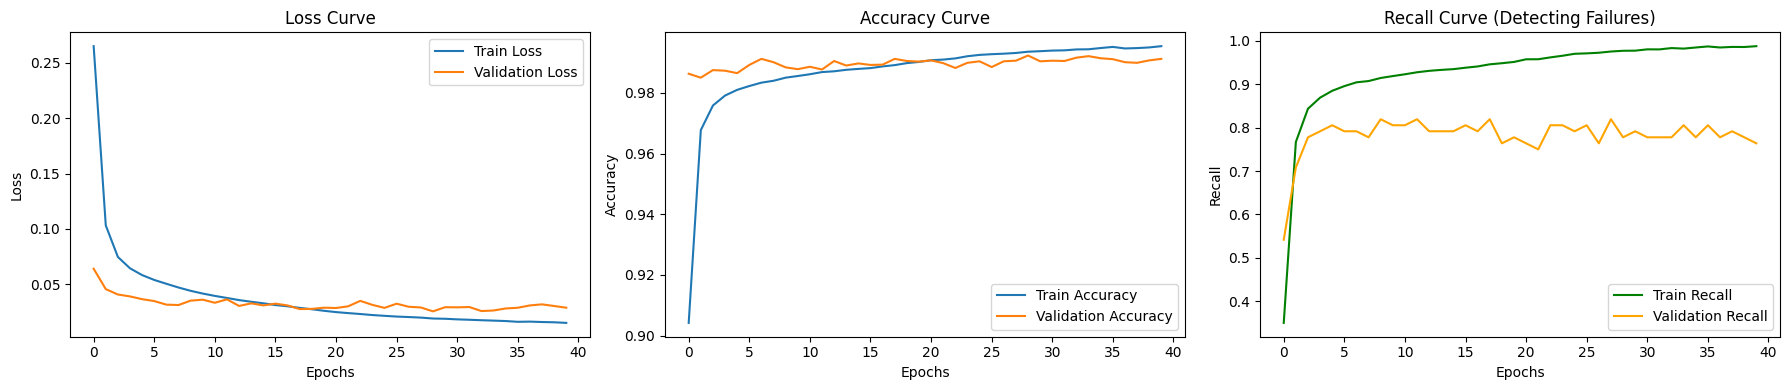

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

--- REPORTE DE CLASIFICACIÓN FINAL (MODELO BALANCEADO) ---
              precision    recall  f1-score   support

         TWF       0.09      0.36      0.14        11
         HDF       0.67      0.94      0.78        17
         PWF       0.72      0.90      0.80        20
         OSF       0.77      0.94      0.85        18
         RNF       0.00      0.00      0.00         6

   micro avg       0.44      0.76      0.56        72
   macro avg       0.45      0.63      0.51        72
weighted avg       0.56      0.76      0.64        72
 samples avg       0.03      0.02      0.02        72


Performance on the TRAIN set, ACCURACY = 0.9966
Performance on the TEST set, ACCURACY = 0.9912


In [19]:
import matplotlib.pyplot as plt

print("Training the balanced model...")

# 1. Training
history_balanced = model_balanced.fit(
    X_train,
    Y_train, # Corregido el nombre de la variable
    epochs=40,
    batch_size=32,
    validation_data=(X_test, Y_test), # Usamos el test real para evitar Data Leakage
    verbose=1
)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 4))

# Graph 1: Loss
ax1.plot(history_balanced.history['loss'], label='Train Loss')
ax1.plot(history_balanced.history['val_loss'], label='Validation Loss')
ax1.set_title('Loss Curve')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.legend()

# Graph 2: Accuracy
ax2.plot(history_balanced.history['binary_accuracy'], label='Train Accuracy')
ax2.plot(history_balanced.history['val_binary_accuracy'], label='Validation Accuracy')
ax2.set_title('Accuracy Curve')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy')
ax2.legend()

# Graph 3: Recall
ax3.plot(history_balanced.history['recall'], label='Train Recall', color='green')
ax3.plot(history_balanced.history['val_recall'], label='Validation Recall', color='orange')
ax3.set_title('Recall Curve (Detecting Failures)')
ax3.set_xlabel('Epochs')
ax3.set_ylabel('Recall')
ax3.legend()

plt.tight_layout()
plt.show()

Y_pred_final = (model_balanced.predict(X_test) > 0.5).astype(int)
print("\n--- REPORTE DE CLASIFICACIÓN FINAL (MODELO BALANCEADO) ---")
print(classification_report(Y_test, Y_pred_final, target_names=label_cols, zero_division=0))

# evaluate() for: [loss, binary_accuracy, precision, recall]
results_train = model_balanced.evaluate(X_train, Y_train, batch_size=32, verbose=0)
results_test = model_balanced.evaluate(X_test, Y_test, batch_size=32, verbose=0)

acc_train = results_train[1]
acc_test = results_test[1]

print(f"\nPerformance on the TRAIN set, ACCURACY = {acc_train:.4f}")
print(f"Performance on the TEST set, ACCURACY = {acc_test:.4f}")

**QUESTION** Plot the confusion matrix and the classification report

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Classification Report (Balanced Model):
              precision    recall  f1-score   support

         TWF       0.11      0.64      0.19        11
         HDF       0.57      1.00      0.72        17
         PWF       0.66      0.95      0.78        20
         OSF       0.74      0.94      0.83        18
         RNF       0.00      0.00      0.00         6

   micro avg       0.37      0.83      0.52        72
   macro avg       0.41      0.71      0.50        72
weighted avg       0.52      0.83      0.62        72
 samples avg       0.03      0.03      0.03        72



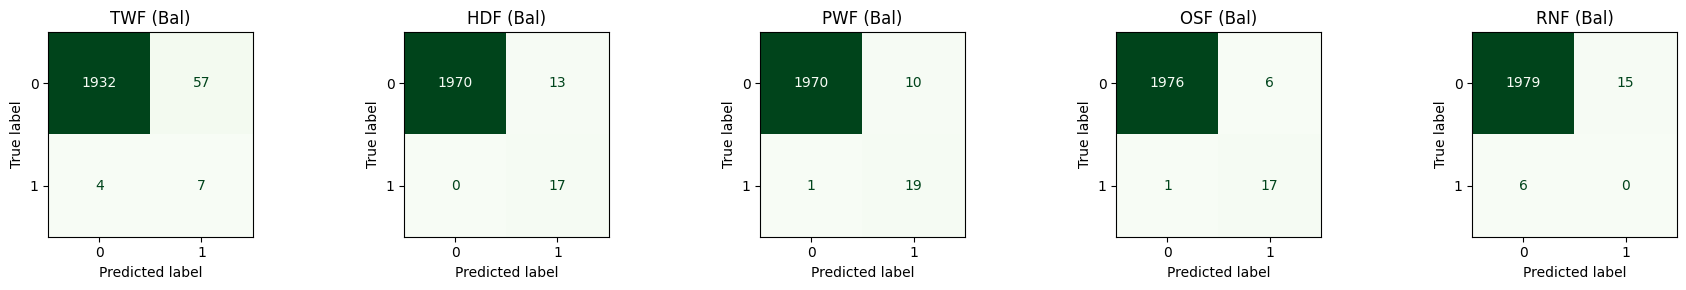

In [20]:
# Predictions on the unseen test set
Y_pred_balanced = (model_balanced.predict(X_test) > 0.3).astype(int)

# Classification Report
print("Classification Report (Balanced Model):")
print(classification_report(Y_test, Y_pred_balanced, target_names=label_cols, zero_division=0))

# Confusion Matrices
fig, axes = plt.subplots(1, 5, figsize=(18, 3))
mcm_balanced = multilabel_confusion_matrix(Y_test, Y_pred_balanced)

for i, (ax, label) in enumerate(zip(axes, label_cols)):
    ConfusionMatrixDisplay(mcm_balanced[i]).plot(ax=ax, colorbar=False, cmap='Greens')
    ax.set_title(label + " (Bal)")

plt.tight_layout()
plt.show()

In [21]:
# Save the model .h5
model_balanced.save('modelo_mantenimiento.h5')

# 2. Download file .h5
from google.colab import files
files.download('modelo_mantenimiento.h5')

converter = tf.lite.TFLiteConverter.from_keras_model(model_balanced)
tflite_model = converter.convert()

with open('modelo_mantenimiento.tflite', 'wb') as f:
    f.write(tflite_model)

files.download('modelo_mantenimiento.tflite')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Saved artifact at '/tmp/tmp51f8m16k'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 6), dtype=tf.float32, name='keras_tensor_4')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  136442187617232: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136442187621840: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136442187620496: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136442187622992: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136442187622416: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136442187620304: TensorSpec(shape=(), dtype=tf.resource, name=None)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**ANALYSIS QUESTION** What do you observe? What can you conclude?

*After lowering the classification threshold from 0.5 to 0.3, the overall recall remained stable while precision slightly decreased. This behavior is expected, as reducing the threshold increases the number of predicted positives, leading to more false positives.
The RNF class still presents zero recall. This is not due to threshold selection but rather to the extremely low number of RNF samples in the dataset and the intrinsic nature of “Random Failure”, which does not appear to follow a clear pattern in the sensor features. Therefore, the model cannot learn meaningful decision boundaries for this class.
This highlights an important limitation of predictive maintenance systems: machine learning models can only learn patterns that are present in the data. Truly random failures cannot be reliably predicted using supervised learning.
Overall, the balanced model significantly improves recall for the main failure types (HDF, PWF, OSF) and partially improves TWF detection, making it more suitable for industrial predictive maintenance applications compared to the unbalanced model.*